# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Data from Example 1.20 / Exercise 1.1 (height/weight):

In [2]:
height = np.array([168, 161, 167, 179, 184, 166, 198, 187, 191, 179])
weight = np.array([65.5, 58.3, 68.1, 85.7, 80.5, 63.4, 102.6, 91.4, 86.7, 78.9])
sigma = np.array([[np.std(height, ddof=1), 0], [0, np.std(weight, ddof=1)]  ])
R = np.corrcoef(height,weight)
S = np.cov(height, weight, ddof=1)

ybar = np.array([height.mean(), weight.mean()])
print(ybar)
print(S)

[178.    78.11]
[[149.11111111 165.92222222]
 [165.92222222 198.01655556]]


---
## Exercise 1.4 (Lecture 5) — Multivariate normal and projections

### a)
**Multivariate normal distribution:** Assume that $Y \sim N(\mu, \Sigma)$, with $\mu = \bar{y}$ and $\Sigma = S$ ($\bar{y}$ and $S$ as in Exercise 1.1), and consider the random variable
$$Q = (Y - \mu)^T \Sigma^{-1} (Y - \mu),$$
what is the expected value and the variance of $Q$?

**Solution:**

By Corollary 9.18, $(Y-\mu)^T\Sigma^{-1}(Y-\mu) \sim \chi^2(n)$ when $Y \sim N_n(\mu,\Sigma)$. Here $Y$ is bivariate ($n=2$), so $Q \sim \chi^2(2)$ and therefore
$$E[Q] = 2, \qquad V[Q] = 2\cdot 2 = 4.$$
Note that the actual values of $\mu = \bar{y}$ and $\Sigma = S$ are irrelevant — the quadratic form standardizes them away.

E[Q]: simulated = 2.0147, theoretical = 2
V[Q]: simulated = 4.1480, theoretical = 4


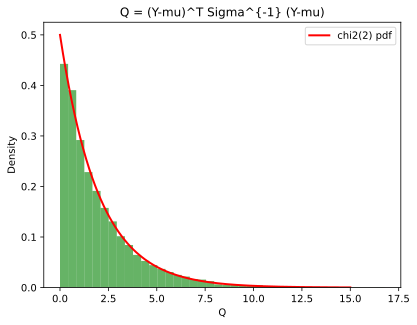

In [3]:
sim_amount = 10000
mu = ybar
Sigma_inv = np.linalg.inv(S)

Y = stats.multivariate_normal.rvs(mean=mu, cov=S, size=sim_amount)
diff = Y - mu
Q = np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff)

print(f"E[Q]: simulated = {Q.mean():.4f}, theoretical = 2")
print(f"V[Q]: simulated = {Q.var(ddof=1):.4f}, theoretical = 4")

plt.hist(Q, bins=40, density=True, alpha=0.6, color='g')
x = np.linspace(0, 15, 200)
plt.plot(x, stats.chi2.pdf(x, df=2), 'r-', lw=2, label='chi2(2) pdf')
plt.title('Q = (Y-mu)^T Sigma^{-1} (Y-mu)')
plt.xlabel('Q')
plt.ylabel('Density')
plt.legend()
plt.show()

### b)
**Orthogonal projections:** Consider the 3 orthogonal projection matrices
$$H_1 = \frac{1}{6}\begin{bmatrix}2&2&2\\2&2&2\\2&2&2\end{bmatrix};\quad H_2 = \frac{1}{6}\begin{bmatrix}4&-2&-2\\-2&1&1\\-2&1&1\end{bmatrix};\quad H_3 = \frac{1}{6}\begin{bmatrix}0&0&0\\0&3&-3\\0&-3&3\end{bmatrix}.$$
With $Z \sim N_3(0, I)$, what is the expectation of the random variables $Q_i = Z^T H_i Z$?

*Hint: Check the sum $H_1 + H_2 + H_3$.*

**Solution:**

The sum is $H_1 + H_2 + H_3 = I_3$, and each $H_i$ is an orthogonal projection with
$$\mathrm{Rank}(H_i) = \mathrm{Trace}(H_i) = 1.$$
The ranks sum to $3 = n$, so Cochran's theorem applies: $Q_i = Z^T H_i Z \sim \chi^2(1)$, mutually independent, hence
$$E[Q_i] = 1, \quad i \in \{1,2,3\}.$$
(In general $E[Z^T H Z] = \mathrm{Trace}(H)$ for $Z \sim N(0,I)$.)

In [4]:
H1 = np.array([[2,2,2],[2,2,2],[2,2,2]]) / 6
H2 = np.array([[4,-2,-2],[-2,1,1],[-2,1,1]]) / 6
H3 = np.array([[0,0,0],[0,3,-3],[0,-3,3]]) / 6

print("H1+H2+H3 = I:", np.allclose(H1 + H2 + H3, np.eye(3)))
print("Traces (= ranks):", np.trace(H1), np.trace(H2), np.trace(H3))

Z = stats.multivariate_normal(mean=np.zeros(3),cov=np.identity(3)).rvs(size=10000)

for i, H in enumerate([H1, H2, H3], start=1):
    Q = np.einsum('ij,jk,ik->i', Z, H, Z)
    print(f"H{i}: E[Q] = {Q.mean():.4f}, V[Q] = {Q.var(ddof=1):.4f}")

H1+H2+H3 = I: True
Traces (= ranks): 1.0 0.9999999999999999 1.0
H1: E[Q] = 0.9907, V[Q] = 1.9434
H2: E[Q] = 1.0205, V[Q] = 2.0331
H3: E[Q] = 1.0247, V[Q] = 2.1684


### c)
Three items are weighed on a scale in the following order ($y_i$ denotes the measurement):

1. Item 1 is put on the scale.
2. Item 1 and 2 is put on the scale.
3. Item 1 and 3 is put on the scale.
4. Item 2 and 3 is put on the scale.

Consider the model $Y = X\beta + \epsilon;\ \epsilon \sim N(0,\sigma^2 I)$ with $\beta \in \mathbb{R}^3$. Write the design matrix $X$ for:

1. $\beta_i$ is the weight of item $i$, i.e. $\beta = [\mu_1, \mu_2, \mu_3]$.
2. $\mu_i = \mu + \delta_i$ with the constraint $\sum \delta_i = 0$, and $\beta = [\mu, \delta_1, \delta_2]$.

Using Python check that the parametrizations are equivalent (same projection matrices).

**Solution:**

Parametrization 1 — each row picks out the items on the scale:
$$X_1 = \begin{bmatrix}1&0&0\\1&1&0\\1&0&1\\0&1&1\end{bmatrix}$$

Parametrization 2 — substitute $\mu_i = \mu + \delta_i$ and $\delta_3 = -\delta_1 - \delta_2$:
- Row 1: $\mu_1 = \mu + \delta_1$
- Row 2: $\mu_1 + \mu_2 = 2\mu + \delta_1 + \delta_2$
- Row 3: $\mu_1 + \mu_3 = 2\mu - \delta_2$
- Row 4: $\mu_2 + \mu_3 = 2\mu - \delta_1$

$$X_2 = \begin{bmatrix}1&1&0\\2&1&1\\2&0&-1\\2&-1&0\end{bmatrix}$$

The models are equivalent iff $H = X(X^TX)^{-1}X^T$ is the same for both.

In [5]:
X1 = np.array([[1,0,0],
               [1,1,0],
               [1,0,1],
               [0,1,1]], dtype=float)

X2 = np.array([[1, 1, 0],
               [2, 1, 1],
               [2, 0,-1],
               [2,-1, 0]], dtype=float)

def hat(X):
    return X @ np.linalg.inv(X.T @ X) @ X.T

H_1, H_2 = hat(X1), hat(X2)
print("Same projection matrix:", np.allclose(H_1, H_2))
print("Rank = Trace(H) =", np.trace(H_1).round(10))

Same projection matrix: True
Rank = Trace(H) = 3.0


---
## Exercise 9.4 — Proof of Corollary 9.18

### a)
Show that when $Y \sim N_n(\mu, \Sigma)$ then $Z = \Lambda^{-1/2} V^T (Y - \mu) \sim N_n(0, I)$, with $V$ and $\Lambda$ as in Lemma 9.3.

**Solution:**

$\Sigma$ is symmetric positive definite, so by Lemma 9.3 it has the eigendecomposition $\Sigma = V \Lambda V^T$ with $V$ orthonormal ($V^TV = VV^T = I$) and $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_n)$, $\lambda_i > 0$.

$Z$ is a linear transformation of a multivariate normal, hence normal. Its mean and covariance are:
$$E[Z] = \Lambda^{-1/2} V^T (E[Y] - \mu) = 0$$
$$V[Z] = \Lambda^{-1/2} V^T \,\Sigma\, V \Lambda^{-1/2} = \Lambda^{-1/2} V^T V \Lambda V^T V \Lambda^{-1/2} = \Lambda^{-1/2} \Lambda \Lambda^{-1/2} = I$$

Hence $Z \sim N_n(0, I)$. $\blacksquare$

In [6]:
# Numerical verification using mu = ybar, Sigma = S
lam,V = np.linalg.eigh(S)
Linv_sqrt = np.diag(1/np.sqrt(lam))

Y = stats.multivariate_normal.rvs(mean=ybar, cov=S, size=sim_amount)
Z = (Linv_sqrt @ V.T @ (Y - ybar).T).T

print("E[Z] ~ 0:", Z.mean(axis=0).round(3))
print("V[Z] ~ I:\n", np.cov(Z.T, ddof=1).round(3))

E[Z] ~ 0: [ 0.003 -0.01 ]
V[Z] ~ I:
 [[ 0.968 -0.005]
 [-0.005  0.997]]


### b)
Prove Corollary 9.18: if $Y \sim N_n(\mu, \Sigma)$ then $(Y-\mu)^T \Sigma^{-1} (Y-\mu) \sim \chi^2(n)$.

**Solution:**

With $\Sigma = V\Lambda V^T$ we have $\Sigma^{-1} = V \Lambda^{-1} V^T = (\Lambda^{-1/2}V^T)^T(\Lambda^{-1/2}V^T)$. Therefore
$$(Y-\mu)^T \Sigma^{-1} (Y-\mu) = \left(\Lambda^{-1/2}V^T(Y-\mu)\right)^T \left(\Lambda^{-1/2}V^T(Y-\mu)\right) = Z^T Z = \sum_{i=1}^n Z_i^2$$
with $Z \sim N_n(0,I)$ from a). A sum of $n$ squared independent standard normals is $\chi^2(n)$. $\blacksquare$

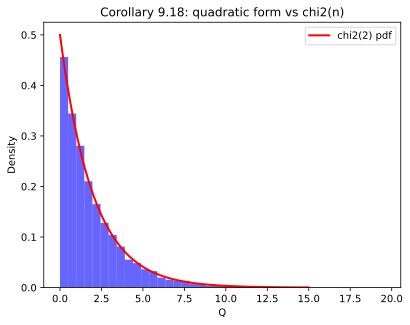

In [7]:
Q = np.einsum('ij,jk,ik->i', Y - ybar, np.linalg.inv(S), Y - ybar)

plt.hist(Q, bins=40, density=True, alpha=0.6, color='b')
x = np.linspace(0, 15, 200)
plt.plot(x, stats.chi2.pdf(x, df=2), 'r-', lw=2, label='chi2(2) pdf')
plt.title('Corollary 9.18: quadratic form vs chi2(n)')
plt.xlabel('Q')
plt.ylabel('Density')
plt.legend()
plt.show()

---
## Exercise 9.5 — Projection matrix

### a)
Use Exercise 9.3 to show that $A$ in (9-49), i.e. $A = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T$ (the centering matrix), is an orthogonal projection matrix.

**Solution:**

We must show $A = A^T$ and $A^2 = A$.

**Symmetry:** $A^T = I^T - \frac{1}{n}(\mathbf{1}\mathbf{1}^T)^T = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T = A$.

**Idempotency:** From Exercise 9.3 a), $A\mathbf{1} = 0$. Then
$$A^2 = A\left(I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^T\right) = A - \tfrac{1}{n}(A\mathbf{1})\mathbf{1}^T = A - 0 = A.$$

Hence $A$ is an orthogonal projection matrix. It projects onto the orthogonal complement of $\mathrm{span}(\mathbf{1})$, with $\mathrm{Rank}(A) = \mathrm{Trace}(A) = n - 1$. $\blacksquare$

In [8]:
n = 10
A = np.eye(n) - np.ones((n, n)) / n

print("Symmetric: ", np.allclose(A, A.T))
print("Idempotent:", np.allclose(A @ A, A))
print("A @ 1 = 0: ", np.allclose(A @ np.ones(n), 0))
print("Trace(A) = ", np.trace(A))

Symmetric:  True
Idempotent: True
A @ 1 = 0:  True
Trace(A) =  9.0


---
## Exercise 9.6 — Proof of Lemma 9.22

### a)
Use Lemma 9.3, property 1 of Lemma 9.22 and Theorem 9.5 to prove property 2 of Lemma 9.22, i.e. that for an orthogonal projection matrix $P$:
$$\mathrm{Rank}(P) = \mathrm{Trace}(P)$$

**Solution:**

$P$ is symmetric, so by Lemma 9.3 it has the eigendecomposition $P = V\Lambda V^T$ with $V$ orthonormal. Using the cyclic property of the trace (Theorem 9.5):
$$\mathrm{Trace}(P) = \mathrm{Trace}(V\Lambda V^T) = \mathrm{Trace}(\Lambda V^T V) = \mathrm{Trace}(\Lambda) = \sum_i \lambda_i$$

By property 1 of Lemma 9.22, the eigenvalues of $P$ are all 0 or 1 and $\mathrm{Rank}(P) = \sum_i \lambda_i$. Combining:
$$\mathrm{Rank}(P) = \sum_i \lambda_i = \mathrm{Trace}(P) \qquad \blacksquare$$

In [9]:
# Demo on the hat matrix from Exercise 1.4 c)
H = hat(X1)
eigvals = np.linalg.eigvalsh(H)

print("Eigenvalues (all 0 or 1):", eigvals.round(10))
print("Rank :", np.linalg.matrix_rank(H))
print("Trace:", np.trace(H).round(10))

Eigenvalues (all 0 or 1): [-0.  1.  1.  1.]
Rank : 3
Trace: 3.0
